In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [17]:
train_dir = '/content/drive/MyDrive/Fruit classifier/train'

In [18]:
train_datagen = ImageDataGenerator(rescale=1./255)

In [19]:
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=4,
        class_mode='binary')

Found 20 images belonging to 2 classes.


In [20]:
model = keras.Sequential([

    keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [22]:
history = model.fit(train_generator, epochs=15)

Epoch 1/15
4/5 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5677 - loss: 2.7167

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6000 - loss: 3.8877
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 834ms/step - accuracy: 0.6500 - loss: 1.9767
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 539ms/step - accuracy: 0.6000 - loss: 0.9802
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - accuracy: 0.6500 - loss: 0.5270
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step - accuracy: 0.8500 - loss: 0.3189
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 713ms/step - accuracy: 0.9500 - loss: 0.2109
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 719ms/step - accuracy: 1.0000 - loss: 0.1063
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 523ms/step - accuracy: 1.0000 - loss: 0.0580
Epoch 9/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 613ms/step - accuracy: 1.0000 - loss: 0.0238
Epoch 10/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 530ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 11/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 922ms/step - accuracy: 1.0000 - loss: 0.0051
Epoch 12/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 534ms/step - accuracy: 1.0000 - loss: 0.0029
Ep

In [26]:
test_apple_path = '/content/drive/MyDrive/Fruit classifier/test/test_apple.jpg'
test_mango_path = '/content/drive/MyDrive/Fruit classifier/test/test_mango.jpg'

In [27]:
class_labels = list(train_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


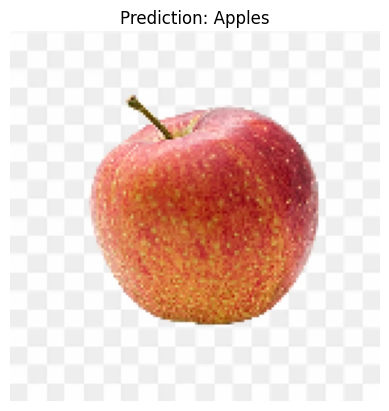

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


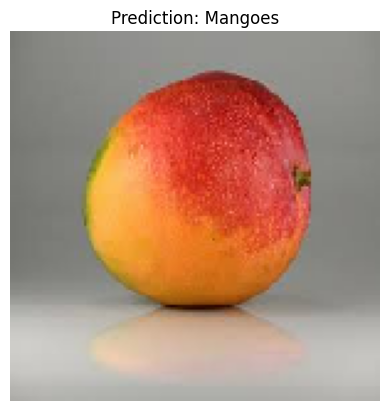

In [29]:
def predict_image(image_path):
  img = keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0
  prediction = model.predict(img_array)

  plt.imshow(img)
  plt.axis('off')

  if prediction[0] >= 0.5:
    predicted_class = class_labels[1]
  else:
    predicted_class = class_labels[0]

  plt.title(f"Prediction: {predicted_class}")
  plt.show()

predict_image(test_apple_path)
predict_image(test_mango_path)